# NB08: 배달 수요 핫스팟 — Baseline Layer (Step 1)

**목적**: 카드매출 수요 + 유동인구 밀집도를 H3 헥사곤 그리드 위에 결합하여 "배송 시급도 지수" 생성

**입력**:
- `processed/card_delivery_demand.parquet` (NB04: 동별 배달수요지수)
- `processed/flow_pop_agg.parquet` (NB05: 동별 유동인구지수)
- `processed/seongnam_boundary.gpkg` (NB01: 행정동 경계)
- `processed/admin_code_crosswalk.csv`

**출력**: `processed/delivery_urgency_grid.gpkg` (H3 hex grid + urgency score per cell)

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import h3
from shapely.geometry import Polygon
from pathlib import Path

BASE = Path(r"C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam")
OUT = BASE / "processed"

# 입력 데이터 로드
demand = pd.read_parquet(OUT / "card_delivery_demand.parquet")
flow_pop = pd.read_parquet(OUT / "flow_pop_agg.parquet")
crosswalk = pd.read_csv(OUT / "admin_code_crosswalk.csv")
seongnam = gpd.read_file(OUT / "seongnam_boundary.gpkg", layer="dong")

print(f"카드 배달수요: {len(demand)} dongs")
print(f"유동인구: {len(flow_pop)} dongs")
print(f"행정동 경계: {len(seongnam)} dongs")

카드 배달수요: 50 dongs
유동인구: 50 dongs
행정동 경계: 50 dongs


## 1. H3 헥사곤 그리드 생성

H3 Resolution 9 ≈ 한 변 ~174m, 면적 ~0.1 km² → 성남시 전역에 약 1,500~2,000개 셀.  
Resolution 8 ≈ 한 변 ~461m, 면적 ~0.74 km² → 약 200~300개 셀.  
**Resolution 9**를 사용하여 충분한 공간 해상도 확보.

In [2]:
H3_RES = 9

def h3_cell_to_polygon(h3_index):
    """H3 셀 인덱스를 Shapely Polygon으로 변환"""
    boundary = h3.cell_to_boundary(h3_index)
    # h3 v4는 (lat, lng) 순서로 반환 → Polygon은 (lng, lat) 필요
    return Polygon([(lng, lat) for lat, lng in boundary])

# 성남시 경계 내 H3 셀 생성
city = seongnam.dissolve()
city_geojson = city.geometry.iloc[0].__geo_interface__

# geo_to_cells: GeoJSON dict → H3 셀 (h3 v4.4+)
h3_cells = list(h3.geo_to_cells(city_geojson, H3_RES))
print(f"H3 Resolution {H3_RES}: {len(h3_cells)} 셀 생성")

# GeoDataFrame으로 변환
hex_geoms = [h3_cell_to_polygon(h) for h in h3_cells]
hex_centers = [h3.cell_to_latlng(h) for h in h3_cells]

gdf_hex = gpd.GeoDataFrame(
    {
        "h3_index": h3_cells,
        "lat": [c[0] for c in hex_centers],
        "lon": [c[1] for c in hex_centers],
    },
    geometry=hex_geoms,
    crs="EPSG:4326",
)
print(f"그리드 생성 완료: {len(gdf_hex)} hexagons")
gdf_hex.head()

H3 Resolution 9: 1947 셀 생성
그리드 생성 완료: 1947 hexagons


,h3_index,lat,lon,geometry
0,8930e153013ffff,37.382330,127.126055,"POLYGON ((127.12778 37.38211, 127.12704 37.383..."
1,8930e024cafffff,37.350658,127.094579,"POLYGON ((127.09631 37.35044, 127.09556 37.351..."
2,8930e1c912fffff,37.428029,127.069637,"POLYGON ((127.07136 37.42781, 127.07062 37.429..."
3,8930e15264bffff,37.410581,127.128442,"POLYGON ((127.13017 37.41036, 127.12943 37.411..."
4,8930e026a07ffff,37.358944,127.074334,"POLYGON ((127.07606 37.35872, 127.07531 37.360..."


## 2. 각 H3 셀에 행정동 매핑 → 동별 지표 할당

각 헥사곤 중심점이 어느 행정동에 속하는지 spatial join으로 결정

In [3]:
# 헥사곤 중심점 → 행정동 spatial join
hex_centers_gdf = gpd.GeoDataFrame(
    gdf_hex[["h3_index"]],
    geometry=gpd.points_from_xy(gdf_hex["lon"], gdf_hex["lat"]),
    crs="EPSG:4326",
)

hex_dong = gpd.sjoin(hex_centers_gdf, seongnam[["CSV_ADMI_CD", "ADM_NM", "GU_NM", "geometry"]],
                     predicate="within", how="left")
hex_dong = hex_dong.drop(columns=["geometry", "index_right"])

# gdf_hex에 동 정보 병합
gdf_hex = gdf_hex.merge(hex_dong[["h3_index", "CSV_ADMI_CD", "ADM_NM", "GU_NM"]], on="h3_index", how="left")

# 카드매출 배달수요 병합
gdf_hex = gdf_hex.merge(
    demand[["admi_cty_no", "delivery_demand_index"]],
    left_on="CSV_ADMI_CD", right_on="admi_cty_no", how="left",
).drop(columns="admi_cty_no")

# 유동인구 지수 병합
gdf_hex = gdf_hex.merge(
    flow_pop[["ADMI_CD", "flow_pop_index"]],
    left_on="CSV_ADMI_CD", right_on="ADMI_CD", how="left",
).drop(columns="ADMI_CD")

print(f"병합 결과: {len(gdf_hex)} hexagons")
print(f"배달수요 null: {gdf_hex['delivery_demand_index'].isna().sum()}")
print(f"유동인구 null: {gdf_hex['flow_pop_index'].isna().sum()}")

병합 결과: 1947 hexagons
배달수요 null: 0
유동인구 null: 0


## 3. 배송 시급도 지수 산출

`urgency = 0.5 * delivery_demand + 0.3 * flow_pop + 0.2 * time_factor`  
(time_factor는 저녁 시간대 수요 비율 — NB04에서 이미 demand에 반영됨, 여기선 0.2를 demand에 추가 가중)

In [4]:
# null은 0으로 채움 (경계 밖 헥사곤)
gdf_hex["delivery_demand_index"] = gdf_hex["delivery_demand_index"].fillna(0)
gdf_hex["flow_pop_index"] = gdf_hex["flow_pop_index"].fillna(0)

# 종합 배송 시급도 지수
gdf_hex["urgency"] = (
    0.6 * gdf_hex["delivery_demand_index"]
    + 0.4 * gdf_hex["flow_pop_index"]
)

print(f"배송 시급도 지수 통계:")
print(gdf_hex["urgency"].describe())
print(f"\n상위 10 셀:")
top = gdf_hex.nlargest(10, "urgency")
print(top[["h3_index", "ADM_NM", "urgency", "delivery_demand_index", "flow_pop_index"]])

배송 시급도 지수 통계:
count    1947.000000
mean        0.236134
std         0.191962
min         0.001860
25%         0.129281
50%         0.184602
75%         0.259075
max         0.855969
Name: urgency, dtype: float64

상위 10 셀:
            h3_index ADM_NM   urgency  delivery_demand_index  flow_pop_index
0    8930e153013ffff   서현1동  0.855969               0.996813        0.644702
26   8930e1530d7ffff   서현1동  0.855969               0.996813        0.644702
29   8930e15311bffff   서현1동  0.855969               0.996813        0.644702
66   8930e153093ffff   서현1동  0.855969               0.996813        0.644702
99   8930e153157ffff   서현1동  0.855969               0.996813        0.644702
101  8930e15044bffff   서현1동  0.855969               0.996813        0.644702
144  8930e153113ffff   서현1동  0.855969               0.996813        0.644702
152  8930e15300bffff   서현1동  0.855969               0.996813        0.644702
171  8930e150453ffff   서현1동  0.855969               0.996813        0.644702
175  893

## 4. 시각화 + 저장

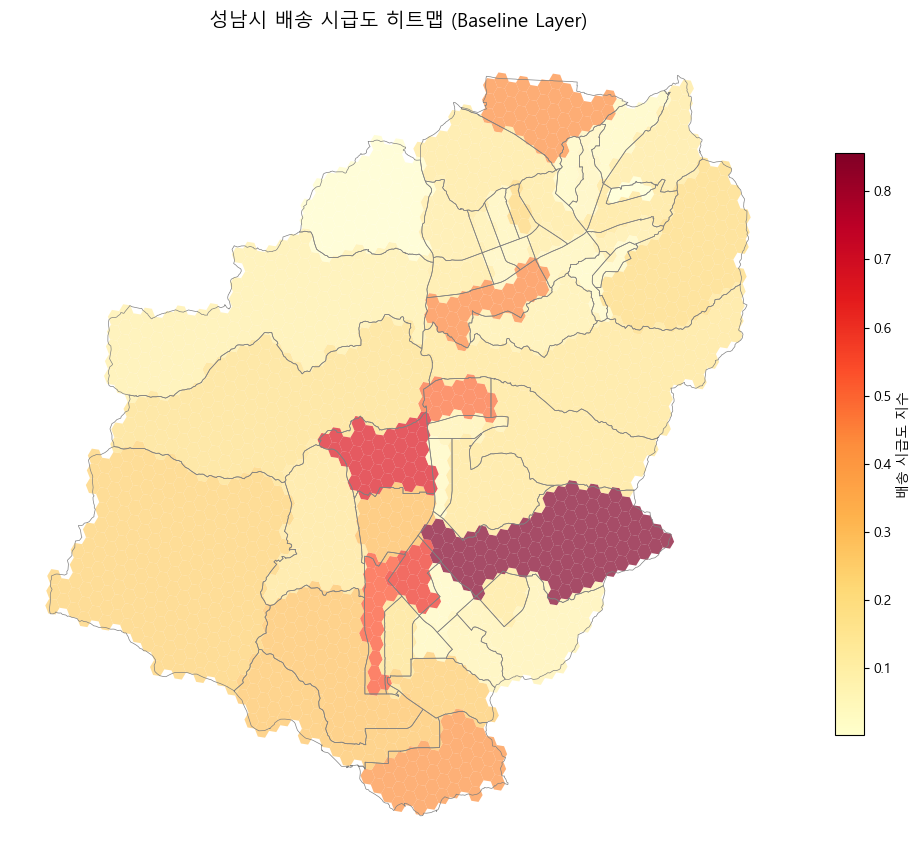

In [5]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 행정동 경계
seongnam.boundary.plot(ax=ax, color="gray", linewidth=0.5)

# 히트맵
gdf_hex.plot(
    ax=ax, column="urgency", cmap="YlOrRd", legend=True,
    alpha=0.7, edgecolor="none",
    legend_kwds={"label": "배송 시급도 지수", "shrink": 0.6},
)

ax.set_title("성남시 배송 시급도 히트맵 (Baseline Layer)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [6]:
# 저장
gdf_hex.to_file(OUT / "delivery_urgency_grid.gpkg", driver="GPKG")
print(f"저장 완료: {OUT / 'delivery_urgency_grid.gpkg'} ({len(gdf_hex)} hexagons)")

저장 완료: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam\processed\delivery_urgency_grid.gpkg (1947 hexagons)
